(200, 25)
         zombieid         age   household       water       human      zombie  \
count  200.000000  200.000000  200.000000  200.000000  200.000000  200.000000   
mean   100.500000   44.415000    2.680000    8.750000    0.605000    0.395000   
std     57.879185   17.371865    1.263162   12.069626    0.490077    0.490077   
min      1.000000   18.000000    1.000000    0.000000    0.000000    0.000000   
25%     50.750000   29.000000    2.000000    0.000000    0.000000    0.000000   
50%    100.500000   42.000000    2.500000    8.000000    1.000000    0.000000   
75%    150.250000   58.000000    4.000000    8.000000    1.000000    1.000000   
max    200.000000   85.000000    6.000000   40.000000    1.000000    1.000000   

          female       male       rural    suburban  ...   no tools  \
count  200.00000  200.00000  200.000000  200.000000  ...  200.00000   
mean     0.49500    0.50500    0.490000    0.240000  ...    0.50500   
std      0.50123    0.50123    0.501154    0.42

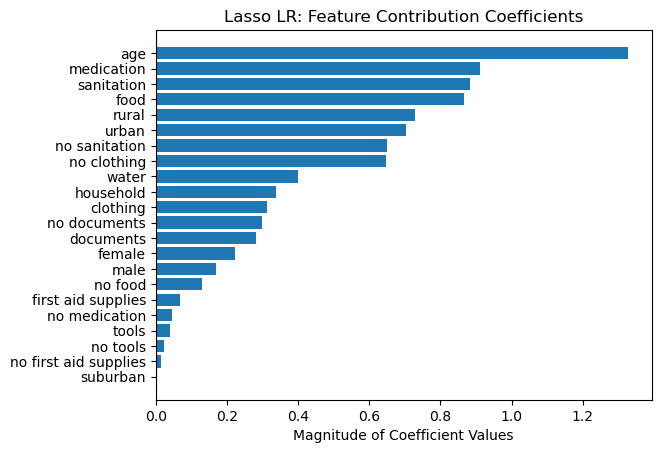

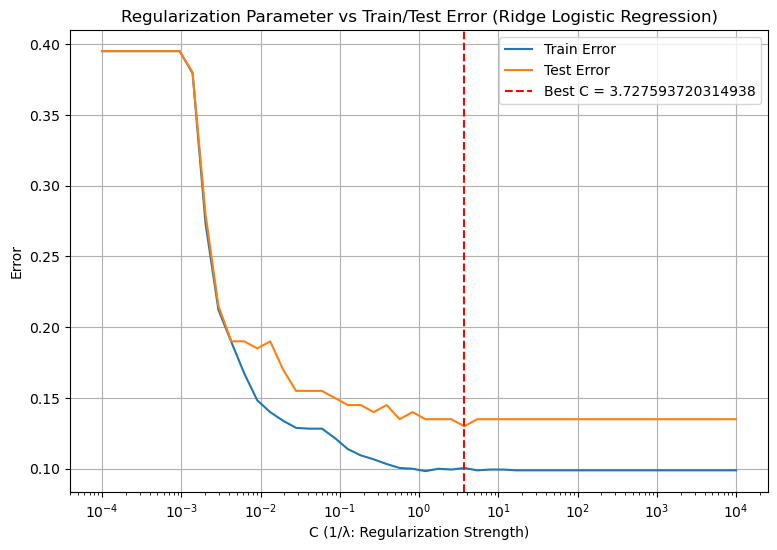

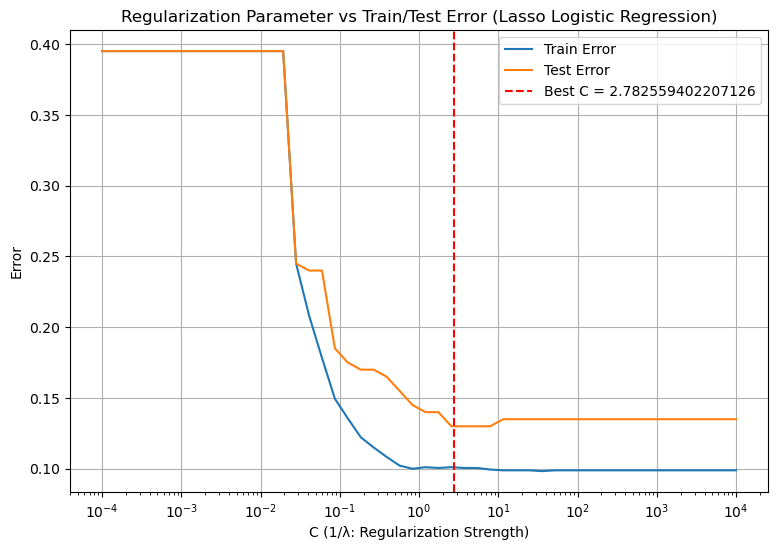

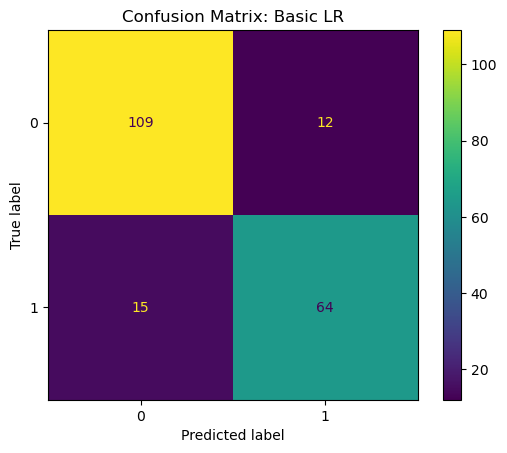

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       121
           1       0.84      0.81      0.83        79

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



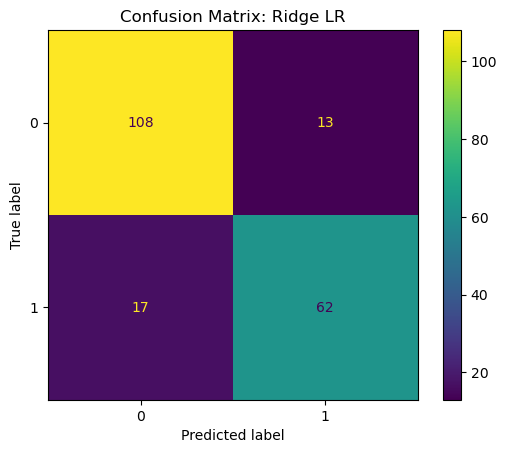

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       121
           1       0.83      0.78      0.81        79

    accuracy                           0.85       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.85      0.85       200



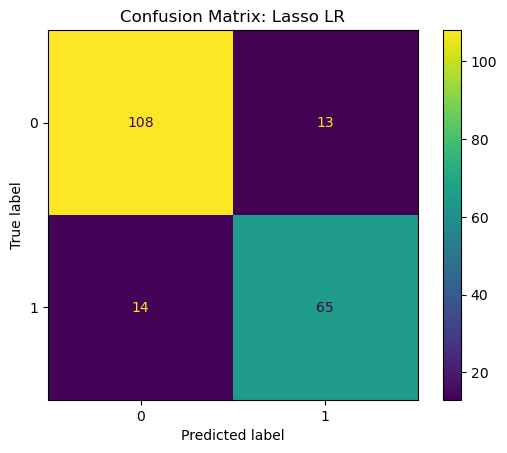

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       121
           1       0.83      0.82      0.83        79

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



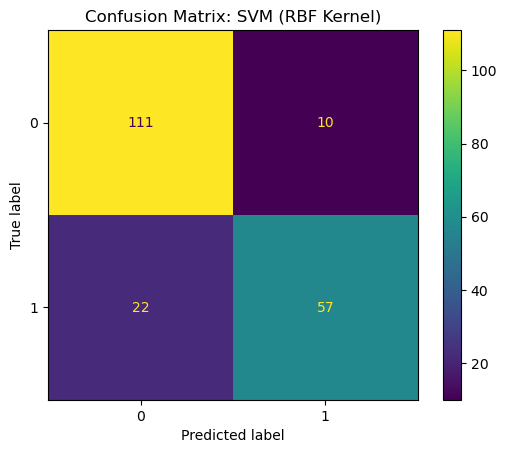

              precision    recall  f1-score   support

           0       0.83      0.92      0.87       121
           1       0.85      0.72      0.78        79

    accuracy                           0.84       200
   macro avg       0.84      0.82      0.83       200
weighted avg       0.84      0.84      0.84       200



In [164]:
# First begin with clearing all credits like "clear, close all, clc" in MATLAB
%reset -f

# Import all the functions used in this classificaiton algorithms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import pandas as pd
import numpy as np

### Load data and set parameters
# the original data from Kaggle was processed through one-hot encoding on Excel and saved as 'zombies_clearned.csv' (available in the Github). 
# The data was then loaded here.
df = pd.read_csv('zombies_cleaned.csv');
# X contains all features excluding the target elements and zombie ID.
# Y contains either 0 or 1, where 1 is zombie and 0 is human
X = df.drop(columns=['zombieid', 'zombie', 'human']);
y = df['zombie'];
# Here, StratifiedKFold was picked for cross-validation method because according to the function discription, this method allows that data to be
# seperated into training and testing, which have the same proportion of class labels as the original dataset, improving reliability of the outcome.
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42);
# Printing the dataset info.
print(df.shape)
print(df.describe())
print(df['zombie'].value_counts(normalize=True))
print()

### Basic Logistic Regression
# There were several ways to create a logistic model, apply 10-fold cross-validation, and fit the training. I decided to use pipeline function here
# because it enables us to include all the process in a single line, which drastically make it simpler and easier to see what is going on.
# For example, by using pipeline and built-in function, I can scale X and Y without creating additional line to assign scaled X into X_train_scale, 
# and so on. This has been done to Basic LR, Ridge LR, and Lasso LR.
# max_iter = 1000 was used because the default max_iter produced warnings that I needed more iterations.
LR = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))])
# The following function calculates the accuracy of Basic Logistic Regression. By saying cv=kf, it is doing 10-fold cross-validation and accuracies
# were recorded throughout all folds, and the average was taken by default.
score_basic = cross_val_score(LR, X, y.values.ravel(), cv=kf)
print("\n===== Logistic Regression Without Regularization =====")
print("Basic Logistic Regression Test accuracy:", f"\nmean = {np.average(score_basic)}", f"\nstd = {np.std(score_basic)}")

### Ridge Logistic Regression
# Here, I generated 50 regularization parameters from 10^-4 to 10^4 with the same logscale increments. Originally, I used 10 samples within the same boundary.
# However, I changed it to 50 because later, I found that 10 samples did not really capture the optimal regularization parameters, so we needed finer C samples.
Cs = np.logspace(-4, 4, 50)
# Similar to the basic LR, a pipeline was used for better visuality. The solver=lbfgs was used not only because it was the default but also because 
# it is good for general dataset. 
RLR_pipeline = Pipeline([('scaler', StandardScaler()), ('lr_cv', LogisticRegressionCV(Cs=Cs, cv=kf, penalty='l2', solver='lbfgs', random_state=42, max_iter=1000))])
score_ridge = cross_val_score(RLR_pipeline, X, y.values.ravel(), cv=kf)
# Again, LogisticRegressionCV is the function that, by defining the type of penalty you use, can output the best regularization parameter. For this section
# R2 was used for Ridge.
RLR_pipeline.fit(X, y.values.ravel())
print("\n===== Logistic Regression With Ridge Regularization =====")
print("Ridge LR Test accuracy:", f"\nmean = {np.average(score_ridge)}", f"\nstd = {np.std(score_ridge)}")
print("Best C found:", RLR_pipeline.named_steps['lr_cv'].C_[0])

### Lasso Logistic Regression
# Everything is basically the same with Ridge, only the penalty was changed to l1, and solver was changed to liblinear because when we tried lbfgs, it
# caused some error saying it does not support l1 penalty.
LLR_pipeline = Pipeline([('scaler', StandardScaler()), ('lr_cv', LogisticRegressionCV(cv=kf, penalty='l1', solver='liblinear', random_state=42, max_iter=1000))])
score_lasso = cross_val_score(LLR_pipeline, X, y.values.ravel(), cv=kf)
LLR_pipeline.fit(X, y.values.ravel())
print("\n===== Logistic Regression With Lasso Regularization =====")
print("Lasso LR Test accuracy:",f"\nmean = {np.average(score_lasso)}", f"\nstd = {np.std(score_lasso)}")
print("Best C found:", LLR_pipeline.named_steps['lr_cv'].C_[0])

### SVM with RBF Kernel
# This part was tricky because we were not able to find a built-in function to find the best C like we did in Ridge and Lasso using LogisticRegressionCV.
# Therefore, we used one of the conventional ways by using GridSearchCV to find the best C. Again, np.logspace(-4,4,10) was used by default. Also, as written
# in the report, SVM with RBF Kernel has extra parameter term, gamma or 1/(sigma^2) (regere to lecture note 14). Therefore, svm_gamma was found by 'scale' 
# technique. This is set as the default and is often considered a good starting point.
SVM = Pipeline([('scaler', StandardScaler()),('svm', SVC(kernel='rbf', random_state=42))])
param_grid_svm = {'svm__C': np.logspace(-4, 4, 10),'svm__gamma': ['scale']}
grid_svm = GridSearchCV(SVM, param_grid_svm, cv=kf, scoring='accuracy')
grid_svm.fit(X, y.values.ravel())
score_svm = cross_val_score(Pipeline([('scaler', StandardScaler()),('svm', SVC(kernel='rbf',C=grid_svm.best_params_['svm__C'],gamma=grid_svm.best_params_['svm__gamma'],random_state=42))]),X, y.values.ravel(), cv=kf)
#SVM_best = Pipeline([('scaler', StandardScaler()),('svm', SVC(kernel='rbf',C=grid_svm.best_params_['svm__C'], gamma=grid_svm.best_params_['svm__gamma'], random_state=42))])
# The following line is later used for the confusion Matrix. This basically creates a new pipeline that generates an optimized SVM with an RBF Kernel model.
SVM_best = Pipeline([('scaler', StandardScaler()),('svm', SVC(kernel='rbf',C=grid_svm.best_params_['svm__C'], gamma=grid_svm.best_params_['svm__gamma'],probability=True, random_state=42))])

print("\n===== SVM with RBF Kernel =====")
print("SVM (RBF Kernel) Test accuracy:", f"\nmean = {np.mean(score_svm)}", f"\nstd = {np.std(score_svm)}")
print("Best C found:", grid_svm.best_params_['svm__C'])
print("Best gamma found:", grid_svm.best_params_['svm__gamma'])

# Summary
# This line was created to generate a summary table of accuracies / standard_deviation between all models evaluated and used for the report.
results = {'Model': ['Basic LR', 'Ridge LR', 'Lasso LR', 'SVM (RBF Kernel)'], 'CV Accuracy (mean)': [np.mean(score_basic), np.mean(score_ridge), np.mean(score_lasso), np.mean(score_svm)], 'CV Accuracy (std)':  [np.std(score_basic),  np.std(score_ridge),  np.std(score_lasso), np.std(score_svm)],};
print("\n===== Summary =====")
print(pd.DataFrame(results).to_string(index=False))

### Important Features & Corresponding Plots
# One of our goals in this project was to find which feature contributes most to the classification. Since we already had the lasso LR, we extracted 
# weight coefficient for each feature, which can be done by using the built-in function, model.named_steps['lr_cv'].coef_[0] according to Scikit-learn
# webpage.
feature_names = X.columns
coefficients = LLR_pipeline.named_steps['lr_cv'].coef_[0]
selected_features = feature_names[coefficients != 0]
print("\n===== Features With Non Zero Weight (Lasso) =====")
print(f"Lasso selected {len(selected_features)} out of {len(feature_names)} features:")
print(selected_features.tolist())

# Since we wanted to plot the magnitude of the contribution coefficient, we first created an SQL table using the pandas DataFrame function so that we
# can use it later to create a bar plot.
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': abs(coefficients)})
# By using .sort_values, all coefficient was reoriented from the smallest to largest so that when we plot it later, it is visually easier to understand
# which features are the top three contributions to the classification.
coef_df = coef_df.sort_values('Coefficient')
#plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.axvline(0, color='black')
plt.title('Lasso LR: Feature Contribution Coefficients')
plt.xlabel('Magnitude of Coefficient Values')
plt.show()

##### C vs Train/Test Error Plot: Ridge #####
# The following lines are basically for plotting the results of the models generated in the previous lines.
# This section visualizes the relationship between error and the increase in regularization parameter C for both training and testing data.
C_values = np.logspace(-4, 4, 50)
# Since we were not able to find the pipeline to do this, we needed to manually create codes that find the accuracy of training/testing for each 
# C values. Also, feature vectors X also needed to be scaled using StandardScaler().
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
train_errors = []
test_errors = []

for C in C_values:
    # Initialize error vector
    train_fold_errors = []
    test_fold_errors = []
    # Using Cross-validation defined in kf, split and generate the index for training and testing.
    for train_idx, test_idx in kf.split(X_scaled, y):
        # Assign features for training
        X_training = X_scaled[train_idx]
        # Assign features for testing
        X_testing = X_scaled[test_idx]
        # Assign label for training
        y_training = y.values[train_idx]
        # Assign label for testing
        y_testing = y.values[test_idx]
        # Generate the Ridge Logistic Regression model by fitting X_training / y_training. Using the model, find score (accuracy) for both testing and
        # training and append the value into the train_fold_erros and test_fold_erros to plot later.
        RLR_model = LogisticRegression(penalty='l2', C=C, max_iter=1000)
        RLR_model.fit(X_training, y_training)
        train_fold_errors.append(1 - RLR_model.score(X_training, y_training))
        test_fold_errors.append(1 - RLR_model.score(X_testing, y_testing))
    train_errors.append(np.mean(train_fold_errors))
    test_errors.append(np.mean(test_fold_errors))

plt.figure(figsize=(9, 6))
plt.plot(C_values, train_errors, label='Train Error')
plt.plot(C_values, test_errors, label='Test Error')
plt.axvline(RLR_pipeline.named_steps['lr_cv'].C_[0], color='red', linestyle='--', label=f"Best C = {RLR_pipeline.named_steps['lr_cv'].C_[0]}")
plt.xscale('log')
plt.xlabel('C (1/λ: Regularization Strength)')
plt.ylabel('Error')
plt.title('Regularization Parameter vs Train/Test Error (Ridge Logistic Regression)')
plt.legend()
plt.grid(True)
plt.show()

### C vs Train/Test Error Plot: Lasso ###
# Pretty much the same as the previous section. penalty and solver changed to l1 and liblinear, repsectively, for Lasso.
train_errors = []
test_errors = []
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
for C in C_values:
    train_fold_errors = []
    test_fold_errors = []
    for train_idx, test_idx in kf.split(X_scaled, y):
        X_training = X_scaled[train_idx]
        X_testing = X_scaled[test_idx]
        y_training = y.values[train_idx]
        y_testing = y.values[test_idx]
        LLR_model = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=1000)
        LLR_model.fit(X_training, y_training)
        train_fold_errors.append(1 - LLR_model.score(X_training, y_training))
        test_fold_errors.append(1 - LLR_model.score(X_testing, y_testing))
    train_errors.append(np.mean(train_fold_errors))
    test_errors.append(np.mean(test_fold_errors))
    
plt.figure(figsize=(9, 6))
plt.plot(C_values, train_errors, label='Train Error')
plt.plot(C_values, test_errors, label='Test Error')
plt.axvline(LLR_pipeline.named_steps['lr_cv'].C_[0], color='red', linestyle='--', label=f"Best C = {LLR_pipeline.named_steps['lr_cv'].C_[0]}")
plt.xscale('log')
plt.xlabel('C (1/λ: Regularization Strength)')
plt.ylabel('Error')
plt.title('Regularization Parameter vs Train/Test Error (Lasso Logistic Regression)')
plt.legend()
plt.grid(True)
plt.show()

### Confusion Matrix
# To generate a confusion matrix, the built-in function 'confusion_matrix()' was used for compactness and simplicity. 
# A for loop was used to make it more compact. Jean-Chrostophe Chouinard's guide on Confusion Matrix which is on Youtube was used for guide to
# create this plot.
for name, pipeline in [('Basic LR', LR), ('Ridge LR', RLR_pipeline), ('Lasso LR', LLR_pipeline), ('SVM (RBF Kernel)', SVM_best)]:
    y_pred = cross_val_predict(pipeline, X, y.values.ravel(), cv=kf)
    cm = confusion_matrix(y, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f'Confusion Matrix: {name}')
    plt.show()
    print(classification_report(y, y_pred))